### Modelo Supervisado:
Se abordó la predicción de la **'Exitosidad' de las aplicaciones** (basada en Rating > 4.2) utilizando las características 'Reviews', 'Category', 'Type' y 'Content Rating'. Se compararon **Random Forest Classifier** y **Logistic Regression**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.cluster import KMeans

# Cargar datos
df = pd.read_csv('../data/googleplaystore.csv')
#display(df)
# Limpieza rápida para que el código no falle
df = df.dropna(subset=['Rating', 'Type', 'Content Rating', 'Current Ver'])
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df = df.dropna(subset=['Reviews'])

# Crear variable objetivo : (Es una app de éxito?)
# Definimos éxito como Rating > 4.2
df['Es_Exitosa'] = (df['Rating'] > 4.2).astype(int)

# Definir variables X (predictoras) e y (objetivo)
# Usaremos estas 4 columnas para el ejemplo
X = df[['Reviews', 'Category', 'Type', 'Content Rating']]
y = df['Es_Exitosa']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos cargados y variables X, y definidas.")

Datos cargados y variables X, y definidas.


### Validación y Métricas:
El rendimiento se evaluó mediante **Validación Cruzada (cv=5)** con `cross_val_score` para obtener una robusta estimación de `Accuracy`. El modelo final fue evaluado con `classification_report` (Precision, Recall, F1-score) y una `Confusion Matrix` sobre el conjunto de prueba (`X_test`, `y_test`).


In [ ]:
# Configurar el preprocesador (Escalado para números, OneHot para categorías)
numeric_features = ['Reviews']
categorical_features = ['Category', 'Type', 'Content Rating']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Crear Pipelines para dos modelos distintos
pipeline_randomforest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_regresionLogistica = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Validación Cruzada
models = {'Random Forest': pipeline_randomforest, 'Regresión Logística': pipeline_regresionLogistica}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name} - Accuracy en Validación Cruzada: {scores.mean():.4f}")

Random Forest - Accuracy en Validación Cruzada: 0.6297
Regresión Logística - Accuracy en Validación Cruzada: 0.5869


### Optimización:
Se utilizó **GridSearchCV** para optimizar los hiperparámetros del Random Forest (`n_estimators`, `max_depth`), buscando maximizar el `f1-score`.


--- Informe de Clasificación Final ---
              precision    recall  f1-score   support

           0       0.63      0.56      0.59       889
           1       0.64      0.70      0.67       984

    accuracy                           0.63      1873
   macro avg       0.63      0.63      0.63      1873
weighted avg       0.63      0.63      0.63      1873

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Reviews']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Type',
                                                   'Content Rating'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, random_state=42))])


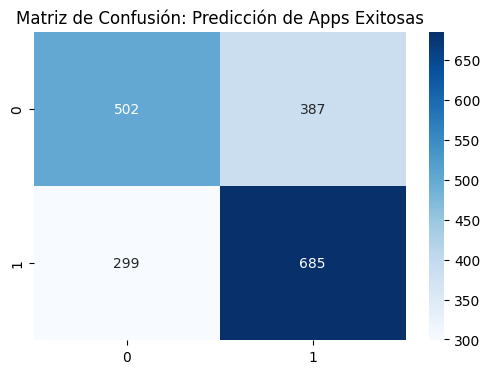

In [ ]:
# Optimización del Random Forest
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10]
}

grid_search = GridSearchCV(pipeline_randomforest, param_grid, cv=3, scoring='f1')
grid_search.fit(X_train, y_train)

# Evaluación con el mejor modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Informe de Clasificación Final ---")
print(classification_report(y_test, y_pred))
print(best_model)
# Visualización de la Matriz de Confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Predicción de Apps Exitosas')
plt.show()

###Modelo No Supervisado:
Se aplicó DBSCAN para segmentar las aplicaciones basándose en 'Reviews' y 'Rating', buscando identificar agrupaciones naturales y ruido. Se evaluó con el silhouette_score (0.6531), indicando una estructura de clústeres razonable. Se realizó un análisis de las características promedio por cada cluster para su interpretación.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos (Usaremos Reviews y Rating para segmentar)
# Filtramos nulos primero
df_sub = df[['Reviews', 'Rating']].dropna()

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sub)

# 2. Configurar y entrenar DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)

# Añadir al DataFrame
df_sub['Cluster_DBSCAN'] = clusters

# Nota: El cluster "-1" representa outliers
print(f"Clusters encontrados: {np.unique(clusters)}")

Clusters encontrados: [-1  0  1  2  3]


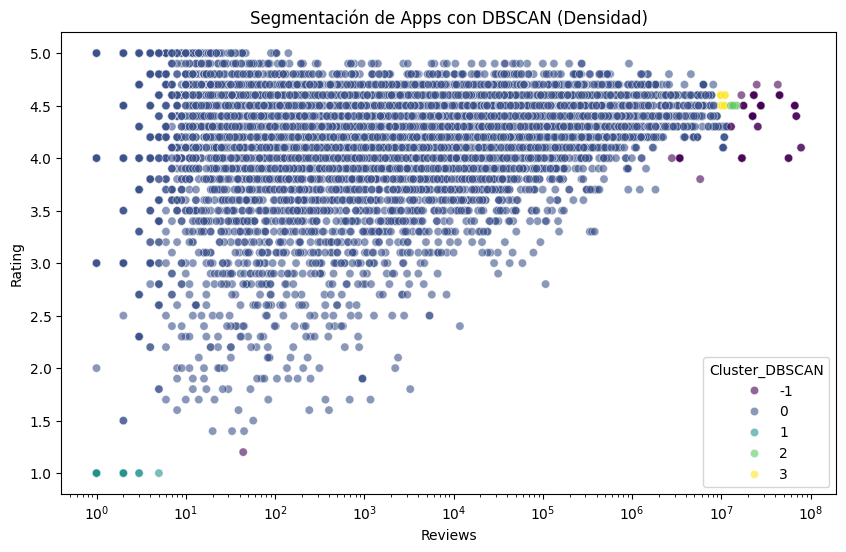

Coeficiente de Silueta: 0.6531


In [ ]:
# Visualización de los resultados
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sub, x='Reviews', y='Rating',
                hue='Cluster_DBSCAN', palette='viridis', alpha=0.6)
plt.title('Segmentación de Apps con DBSCAN (Densidad)')
plt.xscale('log')
plt.show()

# Evaluación con Métrica de Silueta (
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
if n_clusters > 1:
    score = silhouette_score(X_scaled, clusters)
    print(f"Coeficiente de Silueta: {score:.4f}")
else:
    print("DBSCAN solo encontró un grupo o puro ruido. Intenta ajustar 'eps'.")

## Análisis de Características por Cluster

Analizamos las medias de 'Reviews' y 'Rating' para cada cluster identificado, excluyendo el ruido, para comprender mejor los segmentos.

In [ ]:
df_clusters_validos = df_sub[df_sub['Cluster_DBSCAN'] != -1]
cluster_caracteristicas = df_clusters_validos.groupby('Cluster_DBSCAN')[['Reviews', 'Rating']].mean()
display(cluster_caracteristicas)

,Reviews,Rating
Cluster_DBSCAN,,
0,2.944039e+05,4.195669
1,1.750000e+00,1.000000
2,1.408110e+07,4.500000
3,1.027009e+07,4.530000


### Interpretación de los Clusters de DBSCAN

Basándonos en las medias de 'Reviews' y 'Rating', podemos inferir las siguientes características para cada cluster:

*   **Cluster 0:** Este es el grupo más grande, con un número muy alto de `Reviews` (promedio ~294k) y una `Rating` sólida (promedio ~4.2). Representa aplicaciones populares y bien valoradas.
*   **Cluster 1:** Este cluster tiene muy pocas `Reviews` (promedio ~1.7) y una `Rating` muy baja (promedio ~1.0). Podrían ser aplicaciones nuevas, poco usadas o con problemas significativos.
*   **Cluster 2:** Caracterizado por un número extremadamente alto de `Reviews` (promedio ~14M) y una `Rating` muy buena (promedio ~4.5). Estas son las aplicaciones 'superestrellas' o 'viralizadas' de la tienda.
*   **Cluster 3:** Similar al Cluster 2 en cuanto a `Reviews` (promedio ~10M) y `Rating` (promedio ~4.5), lo que sugiere otro grupo de aplicaciones altamente populares y bien valoradas, quizás con un matiz ligeramente diferente en su distribución de `Reviews`.

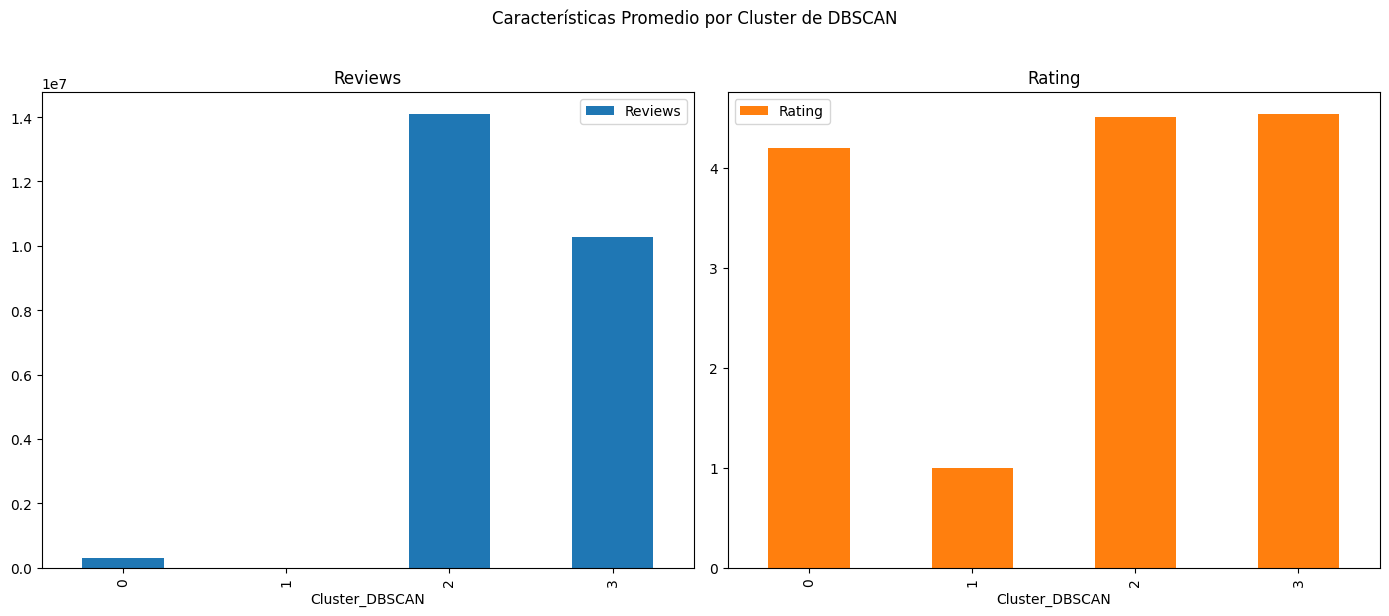

In [ ]:
cluster_caracteristicas.plot(kind='bar', subplots=True, layout=(1, 2), figsize=(14, 6), sharey=False)
plt.suptitle('Características Promedio por Cluster de DBSCAN', y=1.02)
plt.tight_layout()
plt.show()

##Kmeans no supervisado

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cluster = df[['Reviews', 'Rating']]
X_scaled = scaler.fit_transform(X_cluster)
kmeans = KMeans(n_clusters=4, random_state=42)

clusters_kmeans = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters_kmeans

In [ ]:
score_kmeans = silhouette_score(X_scaled, clusters_kmeans)

print("Silhouette Score KMeans:", score_kmeans)

Silhouette Score KMeans: 0.46362589016409966


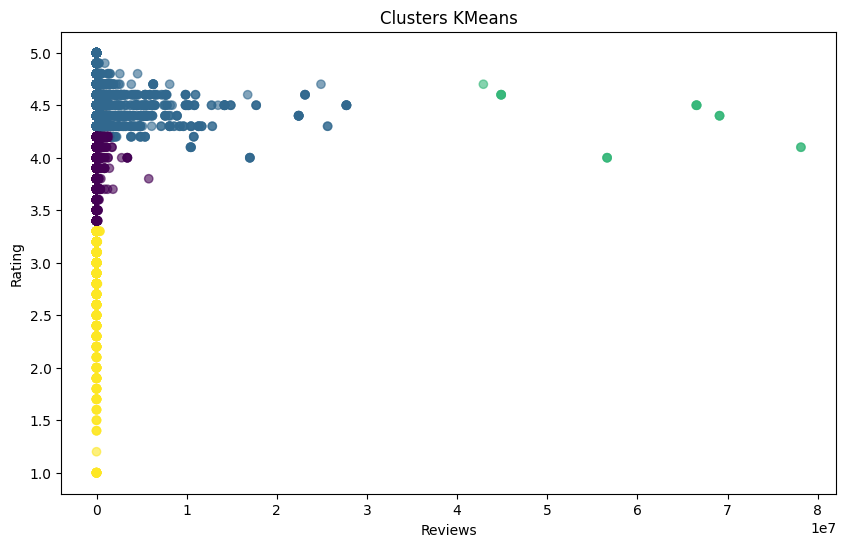

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Reviews'],
    df['Rating'],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Clusters KMeans")
plt.show()

##Comparación entre DBSCAN y K-MEANS

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Variables
X = df[['Reviews', 'Rating']]

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMEANS
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette Score KMeans:", kmeans_score)

# DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_score = silhouette_score(
    X_scaled[dbscan_labels != -1],
    dbscan_labels[dbscan_labels != -1]
)

print("Silhouette Score DBSCAN:", dbscan_score)

Silhouette Score KMeans: 0.46362589016409966
Silhouette Score DBSCAN: 0.6587341460753874
